# Plot of precipitation data availability over the entire time series

In [1]:
import os
os.chdir('/home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/')

# general
import glob
import datetime as dt
from pathlib import Path

# data 
import xarray as xr 
import numpy as np
import pandas as pd

# plotting
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import plotly.express as px 
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio

# Configure Plotly for Jupyter notebooks
pio.renderers.default = "notebook"
# Alternative renderers you can try if "notebook" doesn't work:
# pio.renderers.default = "plotly_mimetype+notebook"
# pio.renderers.default = "jupyter_lab"

# helper tools
from metpy import calc, units
import scipy.stats as stats
from sklearn.linear_model import LinearRegression
from utils.helper_funcs import TaylorDiagram

In [2]:
DATA_DIR = Path("/storage/dlhogan/precipitation-rodeo/data/processed/final/")
OUTPUT_DIR = Path("/home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/")
TABLE_OUTPUT_DIR = Path("/home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/tables/")
GRIDDED_VARS = ['ERA5-Land','PRISM','billy_barr_precip']

In [3]:
def get_dataset(site, directory):
    """Load dataset for a given site."""
    # precipitation datasets
    gothic_prcp_ds = xr.open_dataset(directory / f'{site}_precipitation_30min.nc')
    era5_land_prcp_ds = xr.open_dataset(directory / f'ERA5-Land/era5_land_gothic_1hr.nc')
    prism_prcp_ds = xr.open_dataset(directory / f'PRISM/prism_site_data.nc').sel(site=site)
    ds = xr.merge([gothic_prcp_ds, era5_land_prcp_ds, prism_prcp_ds], compat='override')
    # rename tp to ERA5-Land and ppt to PRISM for clarity
    ds = ds.rename({'tp':'ERA5-Land', 'ppt':'PRISM'})
    # drop crs datavar if it exists
    if 'crs' in ds.data_vars:
        ds = ds.drop_vars('crs')
    return ds

In [4]:
gothic_ds = get_dataset("gothic", DATA_DIR)
kettle_ponds_ds = get_dataset("kettle_ponds", DATA_DIR)

In [5]:
# drop unwanted coordinates
vars_to_drop = ['latitude', 'longitude', 'site', 'spatial_ref', 'lat', 'lon', 'x', 'y', 'sail_pwd_rain', 'sail_squire_rain', 'rain_rate_A']
for var in vars_to_drop:
    if var in gothic_ds.coords or var in gothic_ds.data_vars:
        gothic_ds = gothic_ds.drop_vars(var)
    if var in kettle_ponds_ds.coords or var in kettle_ponds_ds.data_vars:
        kettle_ponds_ds = kettle_ponds_ds.drop_vars(var)

In [18]:
time_slice = slice('2021-10-01', '2023-09-30')
kettle_ponds_df = kettle_ponds_ds.sel(time=time_slice).to_dataframe()
gothic_df = gothic_ds.sel(time=time_slice).to_dataframe()

# get monthly non-nan counts for each instrument/product
kettle_ponds_counts = kettle_ponds_df.replace(0, np.nan).resample('ME').count().transpose() / kettle_ponds_df.resample('ME').size()
gothic_counts = gothic_df.replace(0, np.nan).resample('ME').count().transpose() / gothic_df.resample('ME').size()

# # fill PRISM and ERA5-Land with 1
# kettle_ponds_counts.loc['PRISM'] = 1.0
# kettle_ponds_counts.loc['ERA5-Land'] = 1.0
# gothic_counts.loc['PRISM'] = 1.0
# gothic_counts.loc['ERA5-Land'] = 1.0

# convert 0s to nan for plotting
kettle_ponds_counts = kettle_ponds_counts.replace(0, np.nan)
gothic_counts = gothic_counts.replace(0, np.nan)



In [23]:
kettle_ponds_df.resample('ME').size()

time
2021-10-31    1488
2021-11-30    1440
2021-12-31    1488
2022-01-31    1488
2022-02-28    1344
2022-03-31    1488
2022-04-30    1440
2022-05-31    1488
2022-06-30    1440
2022-07-31    1488
2022-08-31    1488
2022-09-30    1440
2022-10-31    1488
2022-11-30    1440
2022-12-31    1488
2023-01-31    1488
2023-02-28    1344
2023-03-31    1488
2023-04-30    1440
2023-05-31    1488
2023-06-30    1440
2023-07-31    1488
2023-08-31    1488
2023-09-30    1440
Freq: ME, dtype: int64

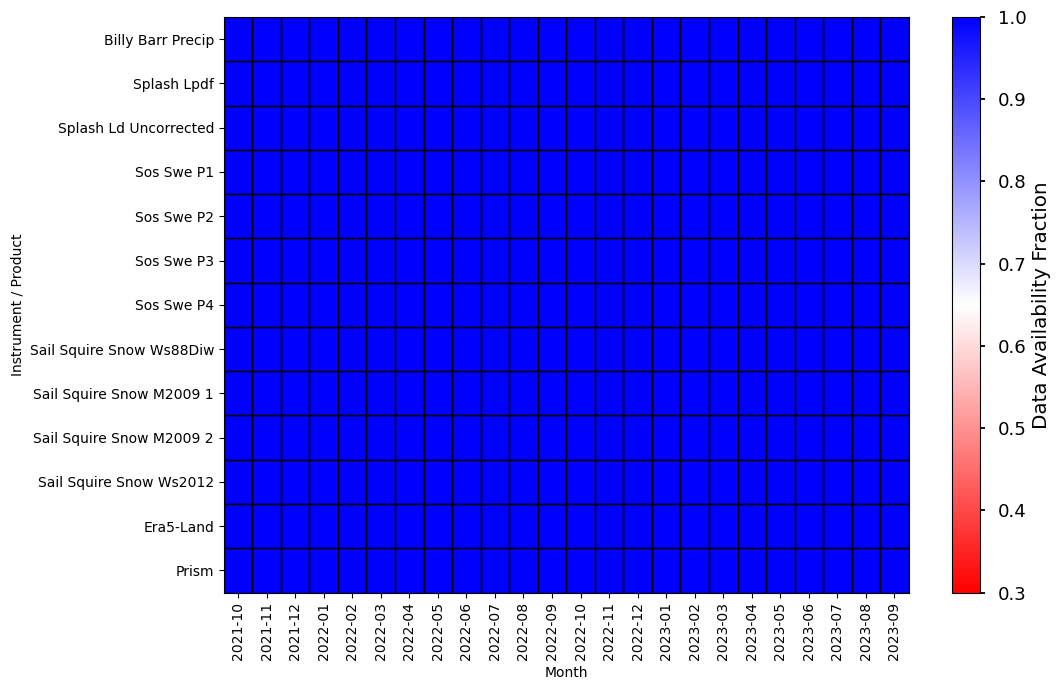

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib

Z = kettle_ponds_counts.values
Z_masked = np.ma.masked_invalid(Z)

x_labels = kettle_ponds_counts.columns.strftime("%Y-%m")
y_labels = kettle_ponds_counts.index.str.replace("_", " ").str.title()

# Colormap that grays out NaN
cmap = matplotlib.colormaps.get_cmap("bwr_r").copy()
cmap.set_bad(color="lightgray")

fig, ax = plt.subplots(figsize=(11, 7))
plt.style.use('seaborn-v0_8-talk')
# Heatmap
cax = ax.imshow(
    Z_masked,
    cmap=cmap,
    vmin=0.3,
    vmax=1.0,
    aspect="auto",
    origin="upper",
)

# Colorbar
cbar = fig.colorbar(cax, ax=ax)
cbar.set_label("Data Availability Fraction")

# Axis labels
ax.set_xticks(np.arange(len(x_labels)))
ax.set_xticklabels(x_labels, rotation=90)

ax.set_yticks(np.arange(len(y_labels)))
ax.set_yticklabels(y_labels)

ax.set_xlabel("Month")
ax.set_ylabel("Instrument / Product")
# ax.set_title("Data Availability Heatmaps")

rows, cols = Z.shape

# Outline + diagonal slash for NaNs
for r in range(rows):
    for c in range(cols):

        # Draw black outline
        rect = plt.Rectangle(
            (c - 0.5, r - 0.5), 1, 1,
            fill=False, edgecolor="black", linewidth=1
        )
        ax.add_patch(rect)

        # If NaN, draw diagonal slash
        if np.isnan(Z[r, c]):
            ax.plot(
                [c - 0.5, c + 0.5],
                [r - 0.5, r + 0.5],
                color="black",
                linewidth=1.5
            )

plt.tight_layout()

plt.savefig(OUTPUT_DIR / 'data_availability_heatmap_kettle_ponds.png', dpi=300)


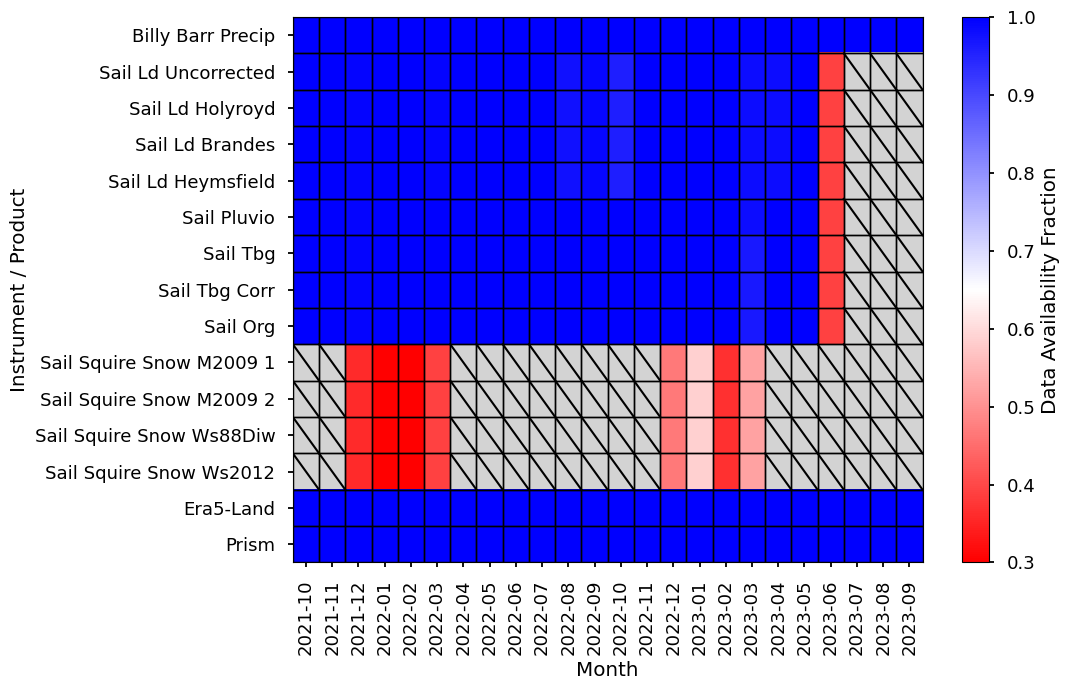

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib

Z = gothic_counts.values
Z_masked = np.ma.masked_invalid(Z)

x_labels = gothic_counts.columns.strftime("%Y-%m")
y_labels = gothic_counts.index.str.replace("_", " ").str.title()

# Colormap that grays out NaN
cmap = matplotlib.colormaps.get_cmap("bwr_r").copy()
cmap.set_bad(color="lightgray")

fig, ax = plt.subplots(figsize=(11, 7))
plt.style.use('seaborn-v0_8-talk')
# Heatmap
cax = ax.imshow(
    Z_masked,
    cmap=cmap,
    vmin=0.3,
    vmax=1.0,
    aspect="auto",
    origin="upper",
)

# Colorbar
cbar = fig.colorbar(cax, ax=ax)
cbar.set_label("Data Availability Fraction")

# Axis labels
ax.set_xticks(np.arange(len(x_labels)))
ax.set_xticklabels(x_labels, rotation=90)

ax.set_yticks(np.arange(len(y_labels)))
ax.set_yticklabels(y_labels)

ax.set_xlabel("Month")
ax.set_ylabel("Instrument / Product")
# ax.set_title("Data Availability Heatmaps")

rows, cols = Z.shape

# Outline + diagonal slash for NaNs
for r in range(rows):
    for c in range(cols):

        # Draw black outline
        rect = plt.Rectangle(
            (c - 0.5, r - 0.5), 1, 1,
            fill=False, edgecolor="black", linewidth=1
        )
        ax.add_patch(rect)

        # If NaN, draw diagonal slash
        if np.isnan(Z[r, c]):
            ax.plot(
                [c - 0.5, c + 0.5],
                [r - 0.5, r + 0.5],
                color="black",
                linewidth=1.5
            )

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'data_availability_heatmap_gothic.png', dpi=300)
